                 A* SEARCH ALGORITHM
Grid Size          : 20 × 20
Start Node         : (0, 0)
Goal Node          : (19, 19)
Obstacle Density   : 20.0%
-----------------------------------------------------------------
Path Found         : YES
Path Length        : 38
Nodes Explored     : 221
Execution Time     : 0.000557 seconds


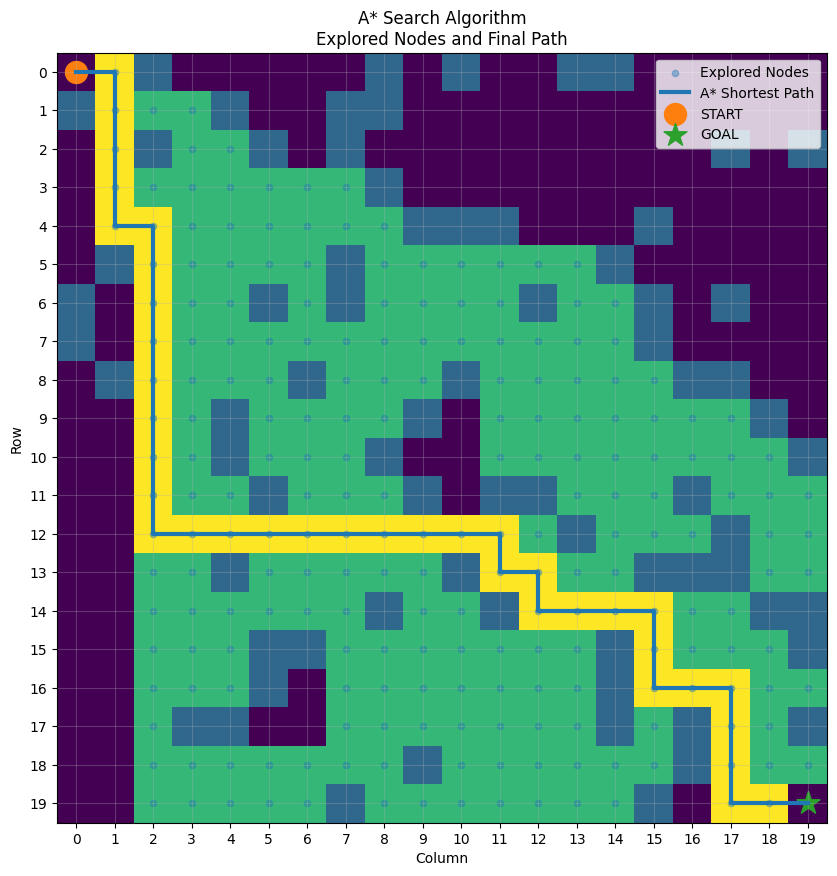


FINAL PATH
--------------------------------------------------
Step 000 : (0, 0)
Step 001 : (0, 1)
Step 002 : (1, 1)
Step 003 : (2, 1)
Step 004 : (3, 1)
Step 005 : (4, 1)
Step 006 : (4, 2)
Step 007 : (5, 2)
Step 008 : (6, 2)
Step 009 : (7, 2)
Step 010 : (8, 2)
Step 011 : (9, 2)
Step 012 : (10, 2)
Step 013 : (11, 2)
Step 014 : (12, 2)
Step 015 : (12, 3)
Step 016 : (12, 4)
Step 017 : (12, 5)
Step 018 : (12, 6)
Step 019 : (12, 7)
Step 020 : (12, 8)
Step 021 : (12, 9)
Step 022 : (12, 10)
Step 023 : (12, 11)
Step 024 : (13, 11)
Step 025 : (13, 12)
Step 026 : (14, 12)
Step 027 : (14, 13)
Step 028 : (14, 14)
Step 029 : (14, 15)
Step 030 : (15, 15)
Step 031 : (16, 15)
Step 032 : (16, 16)
Step 033 : (16, 17)
Step 034 : (17, 17)
Step 035 : (18, 17)
Step 036 : (19, 17)
Step 037 : (19, 18)
Step 038 : (19, 19)

A* COST ANALYSIS
-----------------------------------------------------------------
Node           g(n)        h(n)        f(n)        
-------------------------------------------------------

In [ ]:
# ================================================================
# A* (A-STAR) SEARCH ALGORITHM
# Advanced Google Colab Practical
# ================================================================

import heapq
import random
import time
import matplotlib.pyplot as plt


# ================================================================
# 1. CONFIGURATION
# ================================================================

ROWS = 20
COLS = 20

START = (0, 0)
GOAL = (19, 19)

OBSTACLE_PROBABILITY = 0.20
RANDOM_SEED = 42

random.seed(RANDOM_SEED)


# ================================================================
# 2. CREATE GRID
# ================================================================

def create_grid(rows, cols, obstacle_probability, start, goal):
    """
    Create a 2D grid.

    0 = Free cell
    1 = Obstacle
    """

    grid = []

    for r in range(rows):
        row = []

        for c in range(cols):

            # Keep start and goal free
            if (r, c) == start or (r, c) == goal:
                row.append(0)

            elif random.random() < obstacle_probability:
                row.append(1)

            else:
                row.append(0)

        grid.append(row)

    return grid


grid = create_grid(
    ROWS,
    COLS,
    OBSTACLE_PROBABILITY,
    START,
    GOAL
)


# ================================================================
# 3. HEURISTIC FUNCTION
# ================================================================

def manhattan_distance(node, goal):
    """
    Manhattan Distance:

    h(n) = |x1 - x2| + |y1 - y2|

    Appropriate when movement is restricted to:
        Up
        Down
        Left
        Right
    """

    x1, y1 = node
    x2, y2 = goal

    return abs(x1 - x2) + abs(y1 - y2)


# ================================================================
# 4. GET VALID NEIGHBOURS
# ================================================================

def get_neighbors(node, grid):

    row, col = node

    directions = [
        (-1, 0),   # Up
        (1, 0),    # Down
        (0, -1),   # Left
        (0, 1)     # Right
    ]

    neighbors = []

    rows = len(grid)
    cols = len(grid[0])

    for dr, dc in directions:

        new_row = row + dr
        new_col = col + dc

        # Check grid boundaries
        if 0 <= new_row < rows and 0 <= new_col < cols:

            # Check whether the cell is free
            if grid[new_row][new_col] == 0:

                neighbors.append((new_row, new_col))

    return neighbors


# ================================================================
# 5. RECONSTRUCT FINAL PATH
# ================================================================

def reconstruct_path(came_from, current):
    """
    Reconstruct the final path by moving
    backward from the goal to the start.
    """

    path = [current]

    while current in came_from:

        current = came_from[current]

        path.append(current)

    # Reverse so that path goes START -> GOAL
    path.reverse()

    return path


# ================================================================
# 6. A* SEARCH ALGORITHM
# ================================================================

def a_star(grid, start, goal):

    start_time = time.perf_counter()

    # ------------------------------------------------------------
    # Priority Queue
    # ------------------------------------------------------------

    open_set = []

    counter = 0

    # Initial heuristic
    initial_h = manhattan_distance(start, goal)

    # Store:
    # (f_score, counter, node)

    heapq.heappush(
        open_set,
        (initial_h, counter, start)
    )

    # ------------------------------------------------------------
    # Data structures
    # ------------------------------------------------------------

    # Parent of each node
    came_from = {}

    # g(n): actual cost from START to node
    g_score = {
        start: 0
    }

    # f(n): g(n) + h(n)
    f_score = {
        start: initial_h
    }

    # Nodes already processed
    closed_set = set()

    # Store order in which nodes are explored
    explored_nodes = []

    # ------------------------------------------------------------
    # Main A* loop
    # ------------------------------------------------------------

    while open_set:

        # Get node with lowest f(n)
        current_f, _, current = heapq.heappop(open_set)

        # Ignore nodes already processed
        if current in closed_set:
            continue

        # Mark current node as processed
        closed_set.add(current)

        explored_nodes.append(current)

        # --------------------------------------------------------
        # Goal reached
        # --------------------------------------------------------

        if current == goal:

            path = reconstruct_path(
                came_from,
                current
            )

            execution_time = (
                time.perf_counter() - start_time
            )

            return {
                "path": path,
                "explored": explored_nodes,
                "g_score": g_score,
                "f_score": f_score,
                "execution_time": execution_time,
                "success": True
            }

        # --------------------------------------------------------
        # Explore neighbouring nodes
        # --------------------------------------------------------

        for neighbor in get_neighbors(current, grid):

            # Skip already processed nodes
            if neighbor in closed_set:
                continue

            # Every movement costs 1
            movement_cost = 1

            # Calculate tentative g(n)
            tentative_g = (
                g_score[current] + movement_cost
            )

            # ----------------------------------------------------
            # Check whether this is a better route
            # ----------------------------------------------------

            if (
                neighbor not in g_score
                or tentative_g < g_score[neighbor]
            ):

                # Store parent
                came_from[neighbor] = current

                # Update g(n)
                g_score[neighbor] = tentative_g

                # Calculate h(n)
                h = manhattan_distance(
                    neighbor,
                    goal
                )

                # Calculate f(n)
                f = tentative_g + h

                f_score[neighbor] = f

                counter += 1

                # Add neighbour to priority queue
                heapq.heappush(
                    open_set,
                    (
                        f,
                        counter,
                        neighbor
                    )
                )

    # ============================================================
    # No path found
    # ============================================================

    execution_time = (
        time.perf_counter() - start_time
    )

    return {
        "path": [],
        "explored": explored_nodes,
        "g_score": g_score,
        "f_score": f_score,
        "execution_time": execution_time,
        "success": False
    }


# ================================================================
# 7. RUN A* ALGORITHM
# ================================================================

result = a_star(
    grid,
    START,
    GOAL
)


# ================================================================
# 8. DISPLAY RESULTS
# ================================================================

print("=" * 65)
print("                 A* SEARCH ALGORITHM")
print("=" * 65)

print(f"Grid Size          : {ROWS} × {COLS}")
print(f"Start Node         : {START}")
print(f"Goal Node          : {GOAL}")
print(
    f"Obstacle Density   : "
    f"{OBSTACLE_PROBABILITY * 100:.1f}%"
)

print("-" * 65)

if result["success"]:

    path = result["path"]

    print("Path Found         : YES")
    print(f"Path Length        : {len(path) - 1}")
    print(
        f"Nodes Explored     : "
        f"{len(result['explored'])}"
    )
    print(
        f"Execution Time     : "
        f"{result['execution_time']:.6f} seconds"
    )

else:

    print("Path Found         : NO")
    print(
        f"Nodes Explored     : "
        f"{len(result['explored'])}"
    )
    print(
        "Try reducing OBSTACLE_PROBABILITY "
        "if no path is found."
    )

print("=" * 65)


# ================================================================
# 9. VISUALIZE GRID AND A* SEARCH
# ================================================================

def visualize_grid(
    grid,
    start,
    goal,
    path,
    explored
):

    rows = len(grid)
    cols = len(grid[0])

    # ------------------------------------------------------------
    # Create numerical matrix
    # ------------------------------------------------------------

    matrix = [
        [0 for _ in range(cols)]
        for _ in range(rows)
    ]

    # ------------------------------------------------------------
    # Obstacles
    # ------------------------------------------------------------

    for r in range(rows):
        for c in range(cols):

            if grid[r][c] == 1:
                matrix[r][c] = 1

    # ------------------------------------------------------------
    # Explored nodes
    # ------------------------------------------------------------

    for r, c in explored:

        if (r, c) != start and (r, c) != goal:
            matrix[r][c] = 2

    # ------------------------------------------------------------
    # Final path
    # ------------------------------------------------------------

    for r, c in path:

        if (r, c) != start and (r, c) != goal:
            matrix[r][c] = 3

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    plt.figure(figsize=(10, 10))

    plt.imshow(
        matrix,
        cmap="viridis",
        interpolation="nearest"
    )

    # ------------------------------------------------------------
    # Explored nodes
    # ------------------------------------------------------------

    if explored:

        explored_x = [
            c for r, c in explored
        ]

        explored_y = [
            r for r, c in explored
        ]

        plt.scatter(
            explored_x,
            explored_y,
            s=20,
            alpha=0.4,
            label="Explored Nodes"
        )

    # ------------------------------------------------------------
    # Final path
    # ------------------------------------------------------------

    if path:

        path_x = [
            c for r, c in path
        ]

        path_y = [
            r for r, c in path
        ]

        plt.plot(
            path_x,
            path_y,
            linewidth=3,
            label="A* Shortest Path"
        )

    # ------------------------------------------------------------
    # Start node
    # ------------------------------------------------------------

    plt.scatter(
        start[1],
        start[0],
        s=250,
        marker="o",
        label="START"
    )

    # ------------------------------------------------------------
    # Goal node
    # ------------------------------------------------------------

    plt.scatter(
        goal[1],
        goal[0],
        s=300,
        marker="*",
        label="GOAL"
    )

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------

    plt.title(
        "A* Search Algorithm\n"
        "Explored Nodes and Final Path"
    )

    plt.xlabel("Column")
    plt.ylabel("Row")

    plt.xticks(range(cols))
    plt.yticks(range(rows))

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.show()


# Run visualization
visualize_grid(
    grid,
    START,
    GOAL,
    result["path"],
    result["explored"]
)


# ================================================================
# 10. DISPLAY FINAL PATH
# ================================================================

if result["success"]:

    print("\nFINAL PATH")
    print("-" * 50)

    for step, node in enumerate(result["path"]):

        print(
            f"Step {step:03d} : {node}"
        )


# ================================================================
# 11. A* COST ANALYSIS
# ================================================================

if result["success"]:

    print("\nA* COST ANALYSIS")
    print("-" * 65)

    print(
        f"{'Node':<15}"
        f"{'g(n)':<12}"
        f"{'h(n)':<12}"
        f"{'f(n)':<12}"
    )

    print("-" * 65)

    for node in result["path"]:

        # Actual cost from START
        g = result["g_score"][node]

        # Estimated cost to GOAL
        h = manhattan_distance(
            node,
            GOAL
        )

        # Total estimated cost
        f = g + h

        print(
            f"{str(node):<15}"
            f"{g:<12}"
            f"{h:<12}"
            f"{f:<12}"
        )


# ================================================================
# 12. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 65)
print("                  PRACTICAL SUMMARY")
print("=" * 65)

print("A* uses the following evaluation function:")
print()
print("              f(n) = g(n) + h(n)")
print()
print("g(n) = Actual cost from START to current node")
print("h(n) = Estimated cost from current node to GOAL")
print("f(n) = Estimated total cost through current node")
print()
print("Heuristic Used: Manhattan Distance")
print("Movement      : Up, Down, Left, Right")
print("=" * 65)